In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pennylane as qml

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
input_file = "quantum_encoded_healthcare_data.xlsx"

if not os.path.exists(input_file):
    raise FileNotFoundError(
        f"File not found: {input_file}\n"
        f"Current folder: {os.getcwd()}"
    )

print("Input file found:")
print(os.path.abspath(input_file))

Input file found:
C:\Users\HOME\project-healthcare\notebooks\quantum_encoded_healthcare_data.xlsx


In [3]:
excel_file = pd.ExcelFile(input_file)

print("Available sheets:")

for sheet in excel_file.sheet_names:
    print("-", sheet)

required_sheets = [
    "X_Train_Quantum",
    "X_Test_Quantum",
    "Y_Train",
    "Y_Test"
]

missing_sheets = [
    sheet for sheet in required_sheets
    if sheet not in excel_file.sheet_names
]

if missing_sheets:
    raise ValueError(
        f"Required sheets are missing: {missing_sheets}"
    )

print("\nAll required sheets are available.")

Available sheets:
- X_Train_Quantum
- X_Test_Quantum
- Y_Train
- Y_Test
- Class_Mapping
- Encoding_Quality
- PCA_Summary

All required sheets are available.


In [4]:
X_train_quantum = pd.read_excel(
    input_file,
    sheet_name="X_Train_Quantum"
)

X_test_quantum = pd.read_excel(
    input_file,
    sheet_name="X_Test_Quantum"
)

y_train = pd.read_excel(
    input_file,
    sheet_name="Y_Train"
)

y_test = pd.read_excel(
    input_file,
    sheet_name="Y_Test"
)

print("X_train:", X_train_quantum.shape)
print("X_test :", X_test_quantum.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

display(X_train_quantum.head())

X_train: (400, 4)
X_test : (100, 4)
y_train: (400, 2)
y_test : (100, 2)


,qubit_angle_1,qubit_angle_2,qubit_angle_3,qubit_angle_4
0,-0.598831,0.069103,-0.905760,-1.111189
1,0.235125,-0.575108,1.067584,-0.684806
2,-0.155145,-0.415917,-0.056228,-0.231365
3,-1.075097,0.781873,-0.880525,-2.169215
4,1.534459,-0.569826,-1.888405,0.128655


In [5]:
number_of_qubits = X_train_quantum.shape[1]

if number_of_qubits != 4:
    raise ValueError(
        f"Expected 4 quantum features, found {number_of_qubits}"
    )

X_train_angles = X_train_quantum.to_numpy(
    dtype=float
)

X_test_angles = X_test_quantum.to_numpy(
    dtype=float
)

if np.isnan(X_train_angles).any():
    raise ValueError(
        "Training angles contain missing values."
    )

if np.isnan(X_test_angles).any():
    raise ValueError(
        "Testing angles contain missing values."
    )

if np.isinf(X_train_angles).any():
    raise ValueError(
        "Training angles contain infinite values."
    )

if np.isinf(X_test_angles).any():
    raise ValueError(
        "Testing angles contain infinite values."
    )

print("Number of qubits:", number_of_qubits)
print("Training angles:", X_train_angles.shape)
print("Testing angles:", X_test_angles.shape)
print("Minimum angle:", X_train_angles.min())
print("Maximum angle:", X_train_angles.max())

Number of qubits: 4
Training angles: (400, 4)
Testing angles: (100, 4)
Minimum angle: -3.141592653589793
Maximum angle: 3.141592653589793


In [6]:
wires = list(range(number_of_qubits))

quantum_device = qml.device(
    "default.qubit",
    wires=number_of_qubits
)

print("Quantum simulator created:")
print(quantum_device)

Quantum simulator created:
<default.qubit device (wires=4) at 0x28a165ad990>


In [7]:
def angle_feature_map(features):

    qml.AngleEmbedding(
        features=features,
        wires=wires,
        rotation="Y"
    )
    for wire in range(number_of_qubits - 1):
        qml.CNOT(
            wires=[wire, wire + 1]
        )

    qml.CNOT(
        wires=[
            number_of_qubits - 1,
            0
        ]
    )

In [8]:
@qml.qnode(quantum_device)
def angle_feature_map_circuit(features):

    angle_feature_map(features)

    return qml.probs(
        wires=wires
    )
sample_angles = X_train_angles[0]

angle_probabilities = (
    angle_feature_map_circuit(
        sample_angles
    )
)

print("Input angles:")
print(sample_angles)

print("\nQuantum-state probabilities:")
print(angle_probabilities)

print(
    "\nProbability total:",
    angle_probabilities.sum()
)

Input angles:
[-0.59883077  0.06910302 -0.90576017 -1.11118872]

Quantum-state probabilities:
[5.32194575e-01 2.33537068e-05 4.85713766e-02 1.43475470e-05
 1.50562283e-04 4.62851714e-03 2.45072375e-04 5.07144719e-02
 6.05915072e-05 2.05123072e-01 5.52995662e-06 1.26019091e-01
 1.20087501e-02 5.80310276e-05 1.95468138e-02 6.35843582e-04]

Probability total: 0.9999999999999999


In [9]:
print(
    qml.draw(
        angle_feature_map_circuit
    )(sample_angles)
)

0: ─╭AngleEmbedding(M0)─╭●───────╭X─┤ ╭Probs
1: ─├AngleEmbedding(M0)─╰X─╭●────│──┤ ├Probs
2: ─├AngleEmbedding(M0)────╰X─╭●─│──┤ ├Probs
3: ─╰AngleEmbedding(M0)───────╰X─╰●─┤ ╰Probs

M0 = 
[-0.59883077  0.06910302 -0.90576017 -1.11118872]


In [10]:
iqp_repetitions = 2

def iqp_feature_map(features):

    qml.IQPEmbedding(
        features=features,
        wires=wires,
        n_repeats=iqp_repetitions,
        pattern=[
            [0, 1],
            [1, 2],
            [2, 3],
            [3, 0]
        ]
    )

In [11]:
@qml.qnode(quantum_device)
def iqp_feature_map_circuit(features):

    iqp_feature_map(features)

    return qml.probs(
        wires=wires
    )

In [12]:
iqp_probabilities = (
    iqp_feature_map_circuit(
        sample_angles
    )
)

print("IQP probabilities:")
print(iqp_probabilities)

print(
    "\nProbability total:",
    iqp_probabilities.sum()
)

IQP probabilities:
[4.05745770e-01 1.99242008e-01 1.01871532e-01 1.15887695e-01
 2.19573615e-04 8.88021103e-04 7.98153771e-05 6.76687532e-04
 2.67594930e-02 3.15491454e-02 5.84057452e-02 5.79423569e-02
 1.46878678e-05 2.81668670e-04 2.23408741e-04 2.12391952e-04]

Probability total: 0.9999999999999984


In [13]:
print(
    qml.draw(
        iqp_feature_map_circuit
    )(sample_angles)
)

0: ─╭IQPEmbedding(M0)─┤ ╭Probs
1: ─├IQPEmbedding(M0)─┤ ├Probs
2: ─├IQPEmbedding(M0)─┤ ├Probs
3: ─╰IQPEmbedding(M0)─┤ ╰Probs

M0 = 
[-0.59883077  0.06910302 -0.90576017 -1.11118872]


In [14]:
kernel_device = qml.device(
    "default.qubit",
    wires=number_of_qubits
)

@qml.qnode(kernel_device)
def quantum_kernel_circuit(
    first_features,
    second_features
):

    iqp_feature_map(first_features)

    qml.adjoint(
        iqp_feature_map
    )(second_features)

    return qml.probs(
        wires=wires
    )

In [15]:
def quantum_kernel(
    first_features,
    second_features
):
    probabilities = quantum_kernel_circuit(
        first_features,
        second_features
    )
    return float(probabilities[0])

In [16]:
self_similarity = quantum_kernel(
    X_train_angles[0],
    X_train_angles[0]
)

different_similarity = quantum_kernel(
    X_train_angles[0],
    X_train_angles[1]
)

print("Self-similarity:", self_similarity)
print("Different-record similarity:", different_similarity)

Self-similarity: 0.9999999999999969
Different-record similarity: 0.07568841681201288


In [17]:
def create_kernel_matrix(
    first_dataset,
    second_dataset
):
    kernel_matrix = np.zeros(
        (
            len(first_dataset),
            len(second_dataset)
        )
    )

    for row in range(len(first_dataset)):

        for column in range(
            len(second_dataset)
        ):

            kernel_matrix[
                row,
                column
            ] = quantum_kernel(
                first_dataset[row],
                second_dataset[column]
            )

    return kernel_matrix

In [18]:
kernel_sample_size = 30

X_kernel_sample = X_train_angles[
    :kernel_sample_size
]

training_kernel_sample = create_kernel_matrix(
    X_kernel_sample,
    X_kernel_sample
)

print(
    "Kernel matrix shape:",
    training_kernel_sample.shape
)

Kernel matrix shape: (30, 30)


In [19]:
kernel_symmetric = np.allclose(
    training_kernel_sample,
    training_kernel_sample.T,
    atol=1e-8
)

kernel_diagonal = np.diag(
    training_kernel_sample
)

kernel_eigenvalues = np.linalg.eigvalsh(
    training_kernel_sample
)

kernel_validation = pd.DataFrame({
    "check": [
        "Kernel rows",
        "Kernel columns",
        "Symmetric",
        "Minimum diagonal value",
        "Maximum diagonal value",
        "Minimum eigenvalue",
        "Maximum eigenvalue"
    ],
    "result": [
        training_kernel_sample.shape[0],
        training_kernel_sample.shape[1],
        kernel_symmetric,
        kernel_diagonal.min(),
        kernel_diagonal.max(),
        kernel_eigenvalues.min(),
        kernel_eigenvalues.max()
    ]
})

display(kernel_validation)

,check,result
0,Kernel rows,30
1,Kernel columns,30
2,Symmetric,True
3,Minimum diagonal value,1.0
4,Maximum diagonal value,1.0
5,Minimum eigenvalue,0.091578
6,Maximum eigenvalue,5.78503


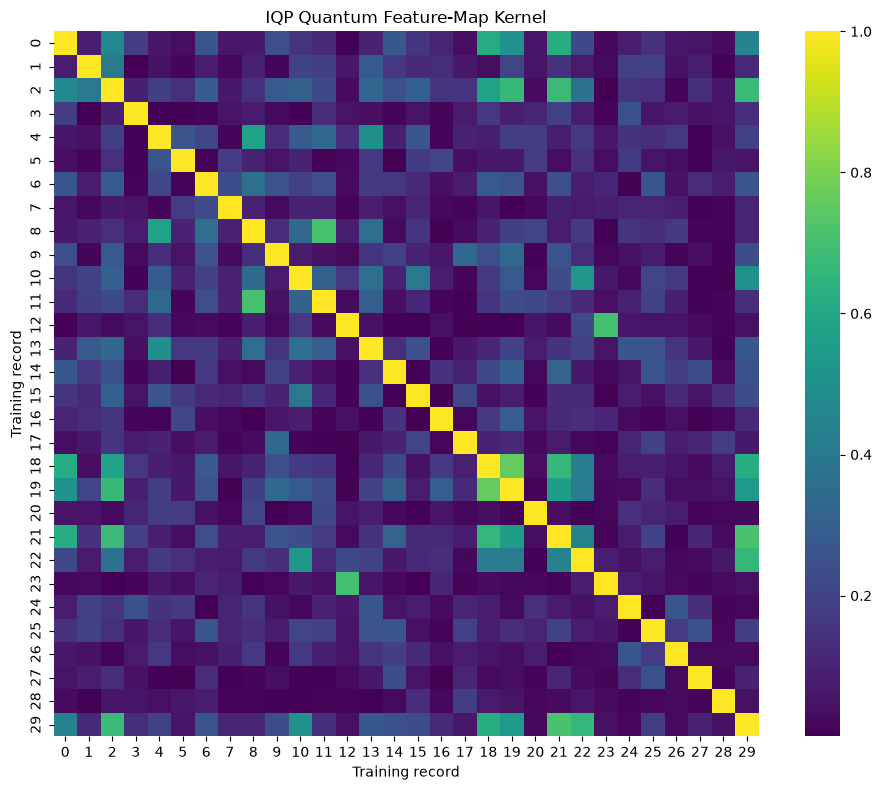

In [20]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    training_kernel_sample,
    cmap="viridis",
    square=True
)

plt.title(
    "IQP Quantum Feature-Map Kernel"
)

plt.xlabel("Training record")
plt.ylabel("Training record")

plt.tight_layout()
plt.show()

In [21]:
feature_map_comparison = pd.DataFrame({
    "feature_map": [
        "Angle Feature Map",
        "IQP Feature Map"
    ],
    "qubits": [
        number_of_qubits,
        number_of_qubits
    ],
    "encoding_repetitions": [
        1,
        iqp_repetitions
    ],
    "entanglement": [
        "CNOT ring",
        "IQP interaction ring"
    ],
    "feature_interactions": [
        "Limited",
        "Included"
    ],
    "recommended_use": [
        "Simple QML baseline",
        "Quantum kernel or advanced QML"
    ]
})

display(feature_map_comparison)

,feature_map,qubits,encoding_repetitions,entanglement,feature_interactions,recommended_use
0,Angle Feature Map,4,1,CNOT ring,Limited,Simple QML baseline
1,IQP Feature Map,4,2,IQP interaction ring,Included,Quantum kernel or advanced QML


In [22]:
feature_map_configuration = {
    "number_of_qubits":
        number_of_qubits,
    "input_features_per_record":
        X_train_angles.shape[1],
    "recommended_feature_map":
        "IQPEmbedding",
    "iqp_repetitions":
        iqp_repetitions,
    "entanglement_pattern": [
        [0, 1],
        [1, 2],
        [2, 3],
        [3, 0]
    ],
    "simulator":
        "default.qubit",
    "kernel_sample_size":
        kernel_sample_size
}

configuration_file = (
    "quantum_feature_map_configuration.json"
)

with open(
    configuration_file,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        feature_map_configuration,
        file,
        indent=4
    )

print("Configuration saved:")
print(os.path.abspath(configuration_file))

Configuration saved:
C:\Users\HOME\project-healthcare\notebooks\quantum_feature_map_configuration.json


In [23]:
kernel_output_file = (
    "quantum_feature_map_results.xlsx"
)

kernel_sample_df = pd.DataFrame(
    training_kernel_sample,
    columns=[
        f"record_{number + 1}"
        for number in range(
            kernel_sample_size
        )
    ],
    index=[
        f"record_{number + 1}"
        for number in range(
            kernel_sample_size
        )
    ]
)

with pd.ExcelWriter(
    kernel_output_file,
    engine="openpyxl"
) as writer:

    feature_map_comparison.to_excel(
        writer,
        sheet_name="Feature_Map_Comparison",
        index=False
    )

    kernel_sample_df.to_excel(
        writer,
        sheet_name="Kernel_Sample"
    )

    kernel_validation.to_excel(
        writer,
        sheet_name="Kernel_Validation",
        index=False
    )

print("Feature-map results saved:")
print(os.path.abspath(kernel_output_file))

Feature-map results saved:
C:\Users\HOME\project-healthcare\notebooks\quantum_feature_map_results.xlsx


In [24]:
assert number_of_qubits == 4
assert X_train_angles.shape == (400, 4)
assert X_test_angles.shape == (100, 4)
assert kernel_symmetric
assert np.allclose(
    kernel_diagonal,
    1.0,
    atol=1e-6
)

print("=" * 60)
print("QUANTUM FEATURE MAP DESIGN COMPLETED")
print("=" * 60)

print("Qubits:", number_of_qubits)
print("Recommended feature map: IQPEmbedding")
print("IQP repetitions:", iqp_repetitions)
print("Kernel sample:", training_kernel_sample.shape)

QUANTUM FEATURE MAP DESIGN COMPLETED
Qubits: 4
Recommended feature map: IQPEmbedding
IQP repetitions: 2
Kernel sample: (30, 30)


In [25]:
assert np.all(
    training_kernel_sample >= -1e-10
)

assert np.all(
    training_kernel_sample <= 1.0 + 1e-10
)

assert kernel_eigenvalues.min() >= -1e-8

print("Kernel range and positive-semidefinite checks passed.")

Kernel range and positive-semidefinite checks passed.
